In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from surprise import Dataset, Reader
import matplotlib.colors as mcolors

ROOT = Path.cwd().resolve()
if (ROOT / 'src').exists():
    pass
elif (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
elif (ROOT.parent.parent / 'src').exists():
    ROOT = ROOT.parent.parent
sys.path.insert(0, str(ROOT))

from src.utils.cluster_simulation import generate_simulation, plot_simulation_distributions_and_heatmap, plot_cluster_ordered_heatmap

from src.utils.popularity import run_topk_loop_with_state, popularity_analysis
from src.features.affinity import affinity_matrix, plot_affinity_heatmap
from src.eval.simulation_metrics import evaluate_run_awpd_observations

Cargar simulación como train

In [2]:
ic = 10
uc = 10
params = dict(
    U=3000,
    I=1682,
    density=0.05,
    alpha_user=0,
    alpha_item=0.45,
    seed=42,
    min_user_ratings=None,
    min_item_ratings=None,
    n_user_clusters=uc,
    n_item_clusters=ic,
    affinity = affinity_matrix(uc, ic, seed=42, kind="bipolar"),
    beta=1.7,
    tau=np.array([-1.2, -0.4, 0.4, 1.2]),
    mu=0,
    sigma_bu=0.5,
    sigma_bi=0.5,
    sigma_eps=0.45,
    gamma=0.5,
)

U, I = params["U"], params["I"]

R_syn, state = generate_simulation(return_state=True, **params)
uc = state["user_cluster"]
ic = state["item_cluster"]
A = state["A"]

ratings_long = pd.DataFrame(R_syn).stack().reset_index()
ratings_long.columns = ["UserID", "MovieID", "Rating"]
reader = Reader(rating_scale=(1, 5))
data_train = Dataset.load_from_df(ratings_long[["UserID", "MovieID", "Rating"]], reader)


Density: 0.05


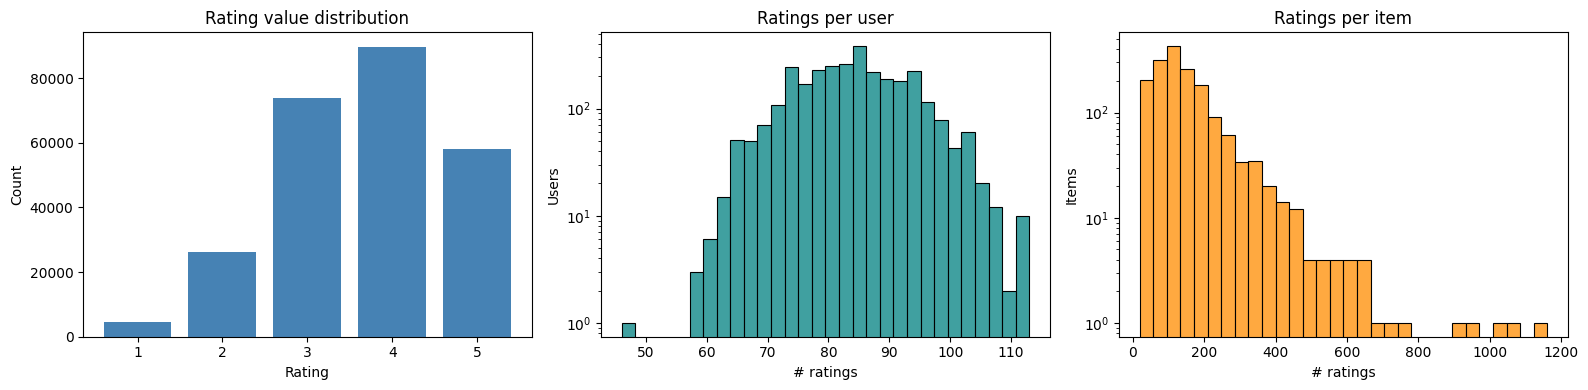

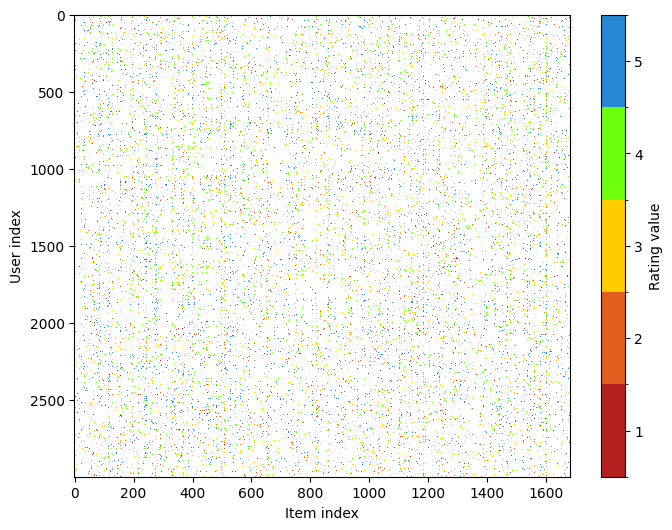

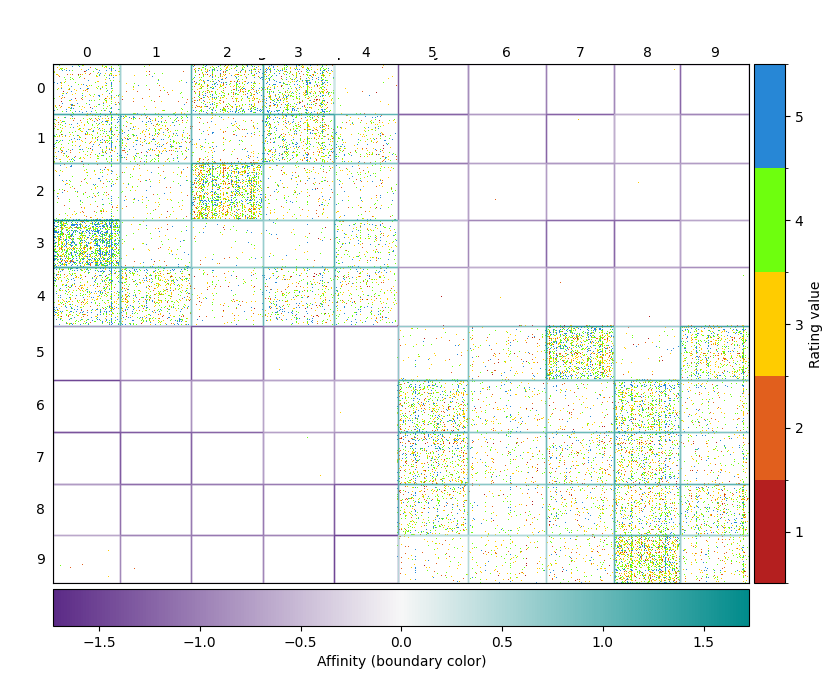

(<Figure size 1000x800 with 9 Axes>,
 array([   0,    7,   10, ..., 2967, 2983, 2999], dtype=int64),
 array([   3,   56,   65, ..., 1668, 1670, 1672], dtype=int64))

In [3]:
plot_simulation_distributions_and_heatmap(R_syn)
plot_cluster_ordered_heatmap(R_syn, uc, ic, A)

In [4]:
ratings_by_model, topk_by_model, data_train_by_model, rmse_df = run_topk_loop_with_state(
    ratings_long=ratings_long,
    reader=reader,
    U=U,
    I=I,
    uc=state["user_cluster"],
    ic=state["item_cluster"],
    state=state,
    A=state.get("A"),
    n_runs=40,
    k=5,
    cooldown_runs=41,
    include_base_in_cooldown=True,
)

## Guardar artefactos para análisis posterior

In [5]:
from pathlib import Path
import numpy as np

ARTIFACTS = ROOT / "artifacts" / "Bipolar"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

# ratings_long: train set original
ratings_long.to_parquet(ARTIFACTS / "ratings_long.parquet", index=False)

# ratings_by_model: all runs per model as separate parquet files
for name, runs in ratings_by_model.items():
    for i, df in enumerate(runs):
        df.to_parquet(ARTIFACTS / f"ratings_{name}_run{i}.parquet", index=False)

# rmse per model per run
rmse_df.to_parquet(ARTIFACTS / "rmse.parquet", index=False)

# simulation state needed for awpd
np.savez(
    ARTIFACTS / "simulation_state.npz",
    user_clusters=uc,
    item_clusters=ic,
    affinity=A,
    popularity=state["pi"],
    num_users=np.array([U]),
)

print("Artefactos guardados en", ARTIFACTS.resolve())

Artefactos guardados en C:\Users\mrari\OneDrive\Desktop\TFG\Sistemas de recomendación\artifacts\Bipolar


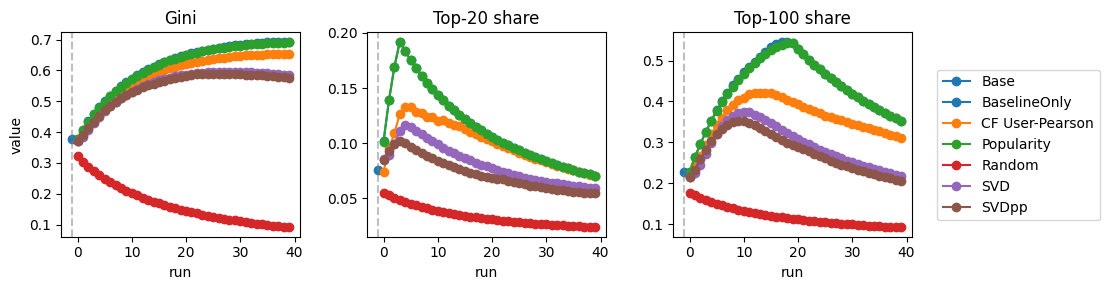

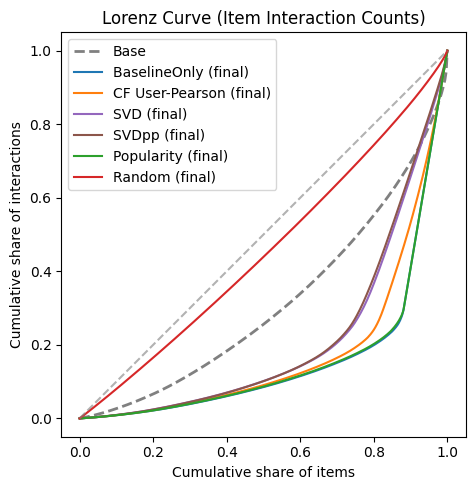

In [6]:
popularity_metrics = popularity_analysis(ratings_by_model)



Density: 0.16890606420927468


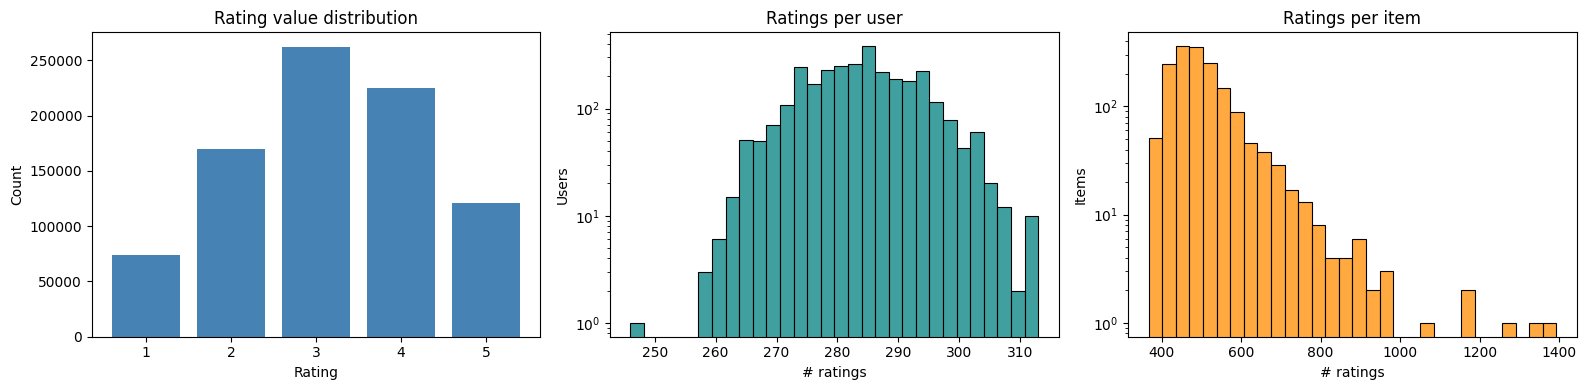

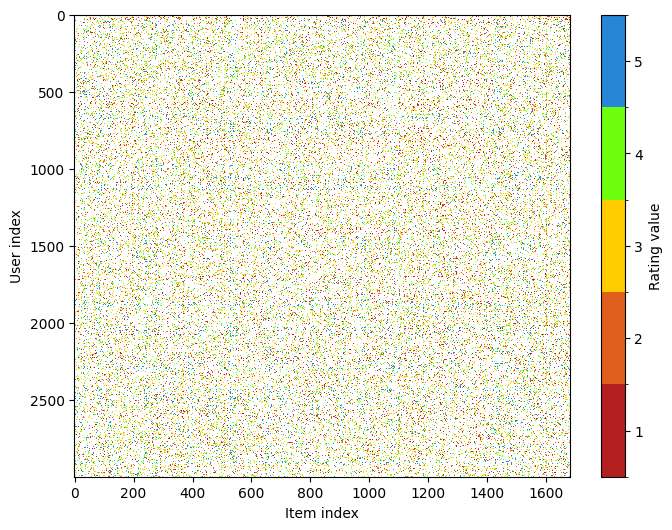

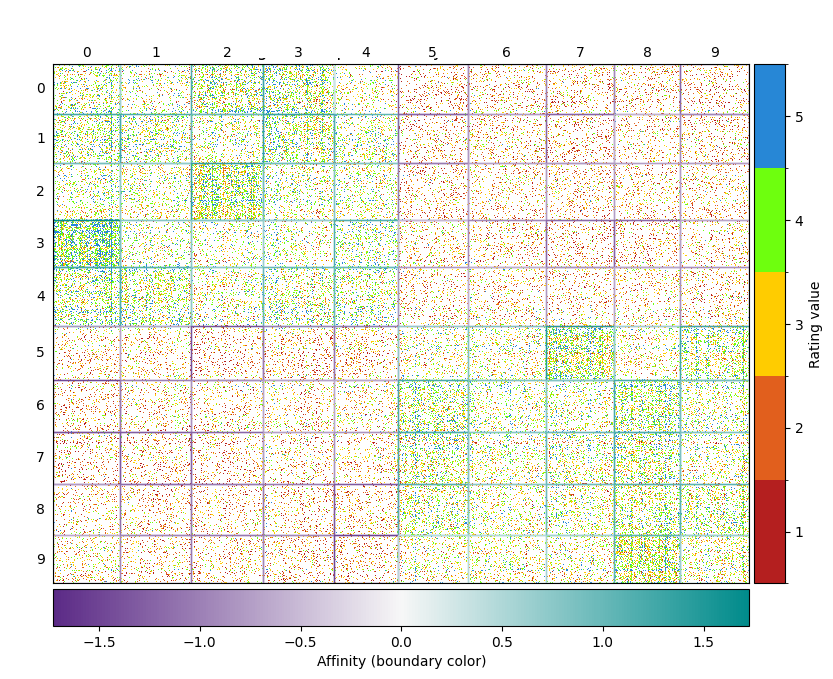

(<Figure size 1000x800 with 9 Axes>,
 array([   0,    7,   10, ..., 2967, 2983, 2999], dtype=int64),
 array([   3,   56,   65, ..., 1668, 1670, 1672], dtype=int64))

In [7]:
ratings_matrix = ratings_by_model["Random"][-1].pivot_table(index='UserID', columns='MovieID', values='Rating')
plot_simulation_distributions_and_heatmap(ratings_matrix)
plot_cluster_ordered_heatmap(ratings_matrix, uc, ic, A)

Density: 0.16890606420927468


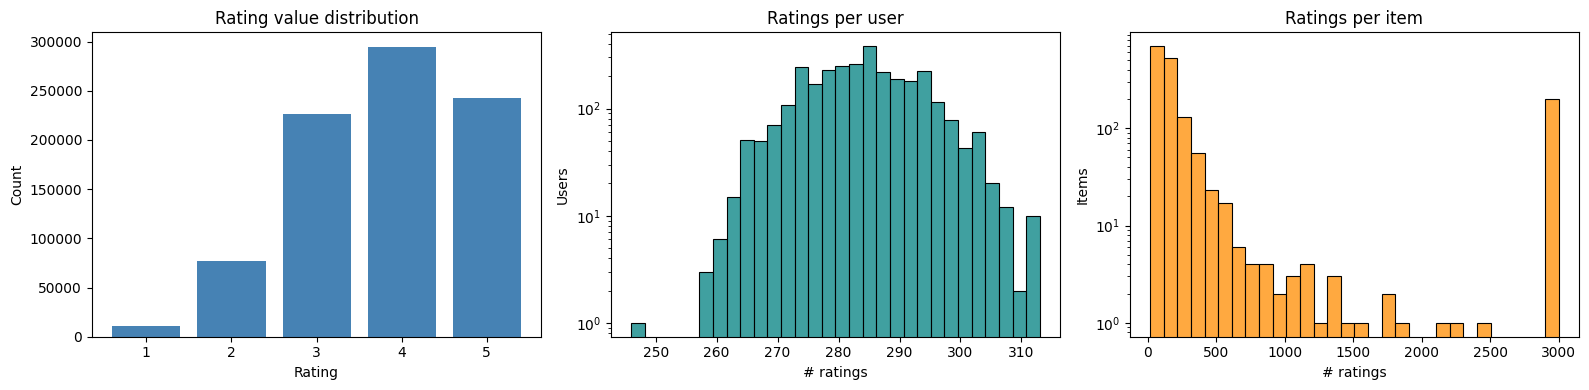

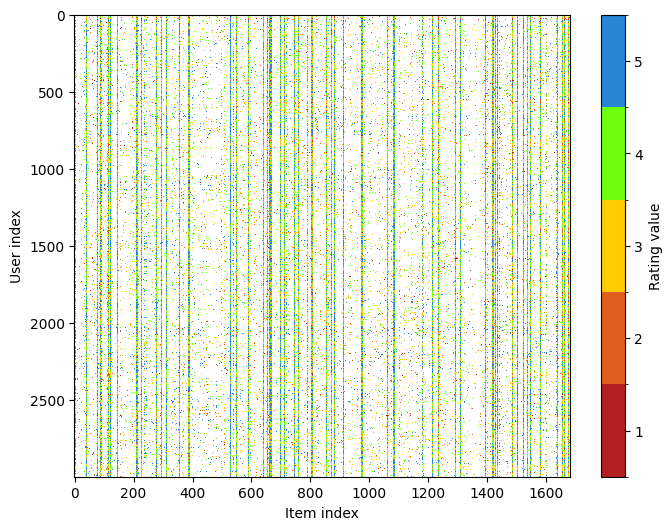

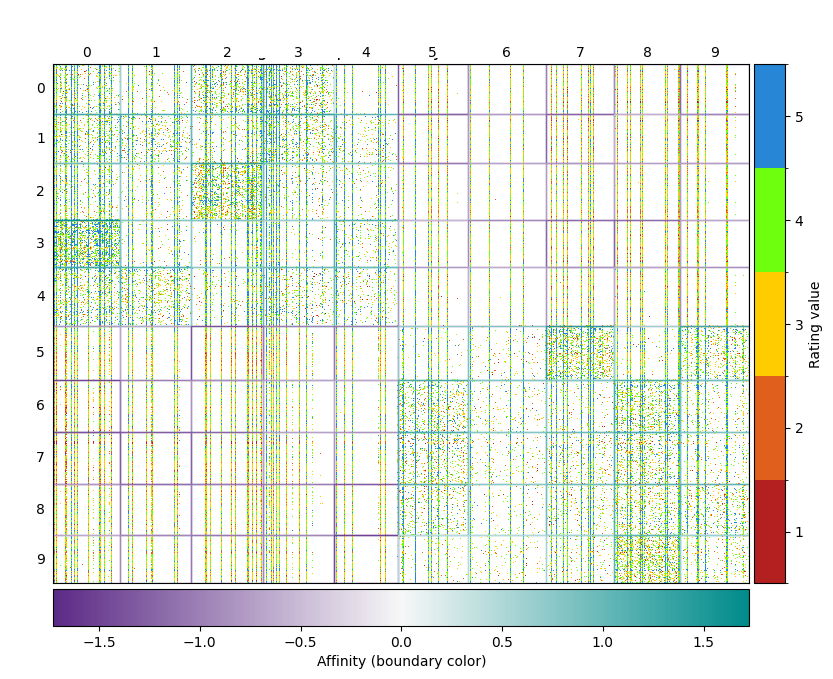

(<Figure size 1000x800 with 9 Axes>,
 array([   0,    7,   10, ..., 2967, 2983, 2999], dtype=int64),
 array([   3,   56,   65, ..., 1668, 1670, 1672], dtype=int64))

In [8]:
ratings_matrix = ratings_by_model["BaselineOnly"][-1].pivot_table(index='UserID', columns='MovieID', values='Rating')
plot_simulation_distributions_and_heatmap(ratings_matrix)
plot_cluster_ordered_heatmap(ratings_matrix, uc, ic, A)

Density: 0.16890606420927468


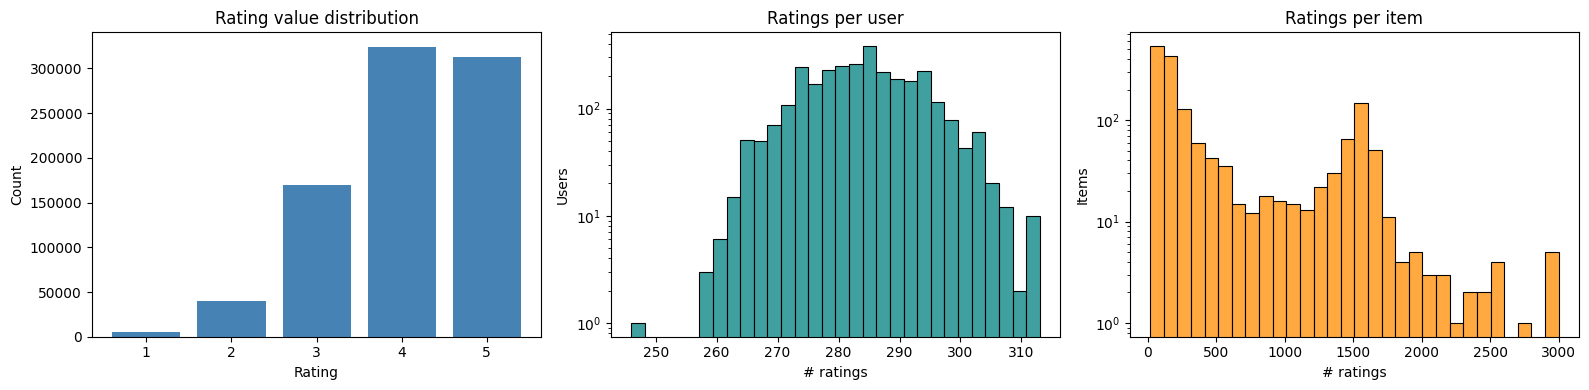

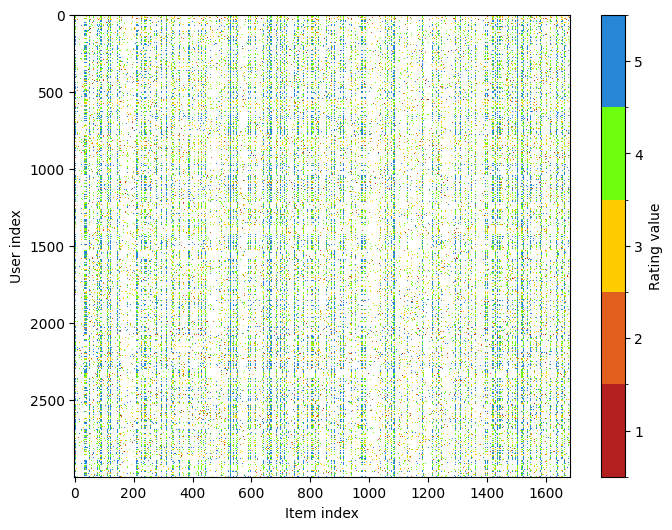

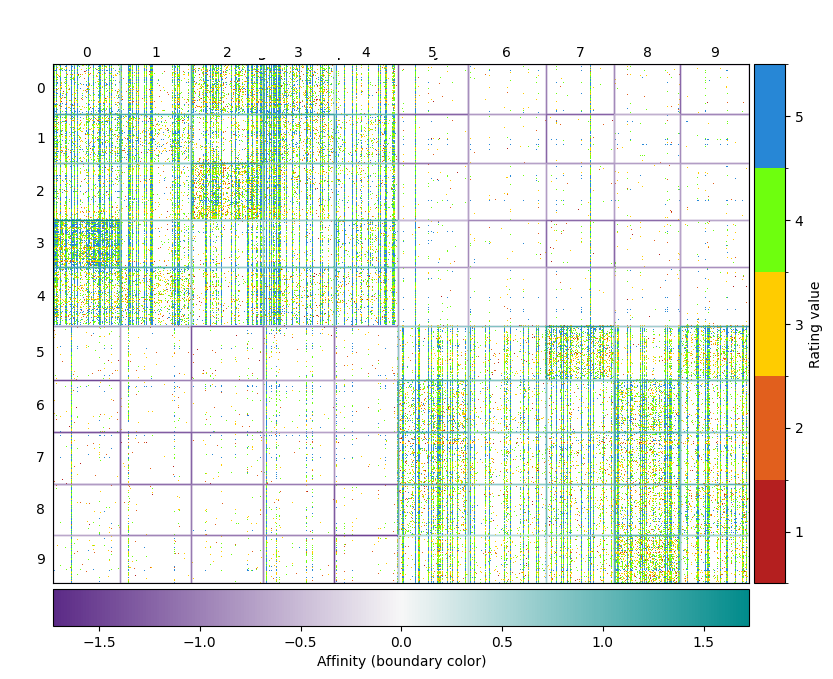

(<Figure size 1000x800 with 9 Axes>,
 array([   0,    7,   10, ..., 2967, 2983, 2999], dtype=int64),
 array([   3,   56,   65, ..., 1668, 1670, 1672], dtype=int64))

In [9]:
ratings_matrix = ratings_by_model["SVD"][-1].pivot_table(index='UserID', columns='MovieID', values='Rating')
plot_simulation_distributions_and_heatmap(ratings_matrix)
plot_cluster_ordered_heatmap(ratings_matrix, uc, ic, A)

Density: 0.16890606420927468


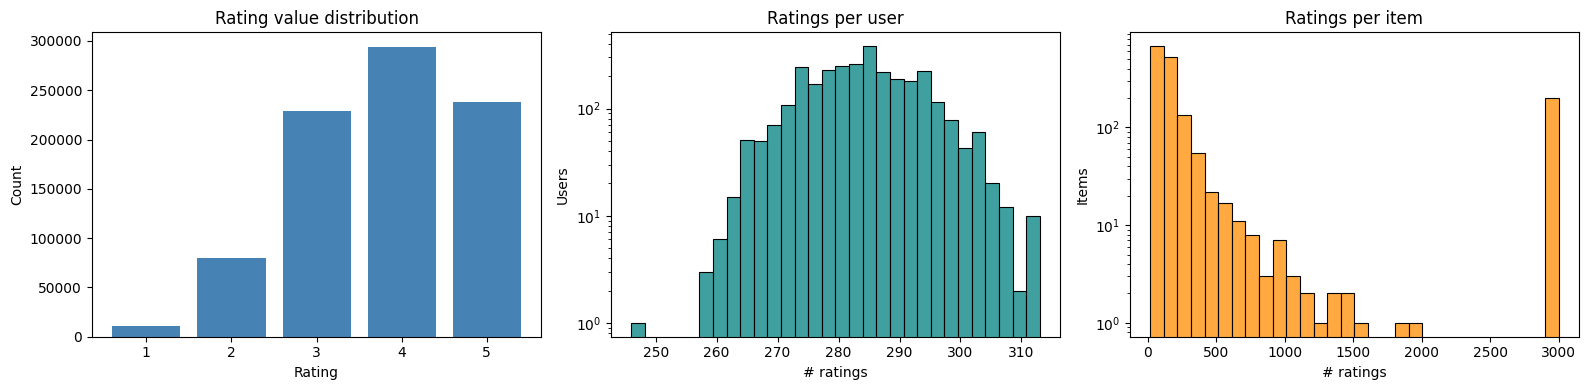

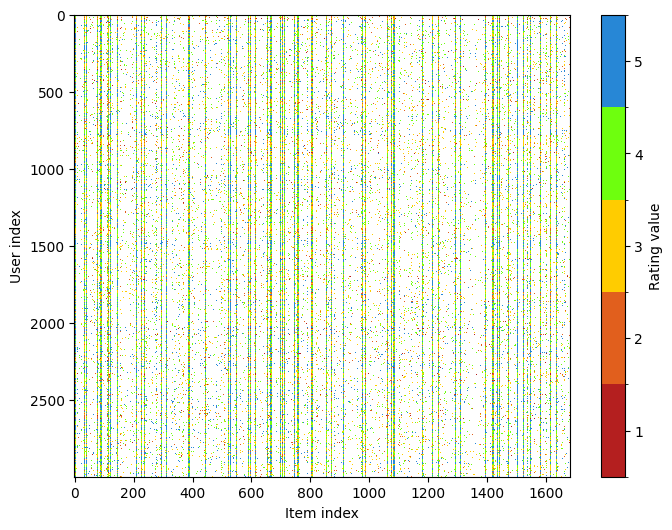

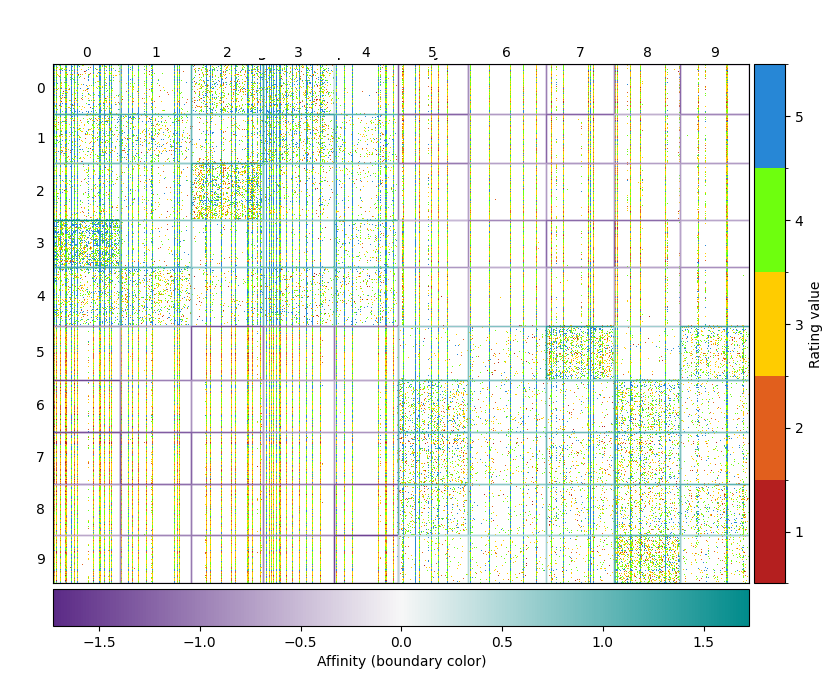

(<Figure size 1000x800 with 9 Axes>,
 array([   0,    7,   10, ..., 2967, 2983, 2999], dtype=int64),
 array([   3,   56,   65, ..., 1668, 1670, 1672], dtype=int64))

In [10]:
ratings_matrix = ratings_by_model["Popularity"][-1].pivot_table(index='UserID', columns='MovieID', values='Rating')
plot_simulation_distributions_and_heatmap(ratings_matrix)
plot_cluster_ordered_heatmap(ratings_matrix, uc, ic, A)